<a href="https://colab.research.google.com/github/teemus28/Machine-Learning/blob/main/ML_XG_boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
cgpa=np.random.uniform(5,10)
cgpa

hired = np.random.choice([0, 1], size=100)

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files


# Generate a sample dataset (replace this with your actual dataset)
data = {
    'CGPA': [8.5, 9.0, 7.8, 8.2, 9.5],
    'IQ Level': [120, 130, 110, 115, 140],
    '12th Marks': [85, 92, 78, 80, 95],
    'Salary': [7.5, 8.2, 6.8, 7.2, 8.8]
}
# data = pd.read_csv("Job_Place_XGboost.csv")
# data = pd.read_csv(io.BytesIO(uploaded['']))
df = pd.DataFrame(data)

# Split the data into features and target variable
X = df[['CGPA', 'IQ Level', '12th Marks']]
y = df['Salary']

# Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Initialize the XGBoost regressor
# xgb_model = XGBRegressor()

# # Train the model
# xgb_model.fit(X_train, y_train)

# # Get predictions on the test set
# predictions = xgb_model.predict(X_test)

# # Visualize the predicted vs actual values
# plt.figure(figsize=(10, 6))

# sns.scatterplot(x=y_test, y=predictions)
# plt.title('XGBoost Regression: Actual vs Predicted')
# plt.xlabel('Actual Values')
# plt.ylabel('Predicted Values')

# plt.show()


In [ ]:
df

,CGPA,IQ Level,12th Marks,Salary
0,8.5,120,85,7.5
1,9.0,130,92,8.2
2,7.8,110,78,6.8
3,8.2,115,80,7.2
4,9.5,140,95,8.8


Text(0.5, 1.0, 'XG Boost')

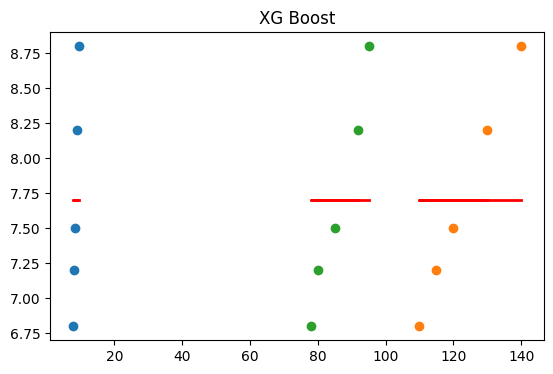

In [ ]:
df['pred1']= df['Salary'].mean()
df
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X, df['pred1'], linewidth=2,color='red')
plt.scatter(df['CGPA'],df['Salary'])
plt.scatter(df['IQ Level'],df['Salary'])
plt.scatter(df['12th Marks'],df['Salary'])
plt.title('XG Boost')

In [ ]:
df['res1']=df['Salary']-df['pred1']
df

,CGPA,IQ Level,12th Marks,Salary,pred1,res1
0,8.5,120,85,7.5,7.7,-0.2
1,9.0,130,92,8.2,7.7,0.5
2,7.8,110,78,6.8,7.7,-0.9
3,8.2,115,80,7.2,7.7,-0.5
4,9.5,140,95,8.8,7.7,1.1


In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree1= DecisionTreeRegressor(max_depth=5)
X

,CGPA,IQ Level,12th Marks
0,8.5,120,85
1,9.0,130,92
2,7.8,110,78
3,8.2,115,80
4,9.5,140,95


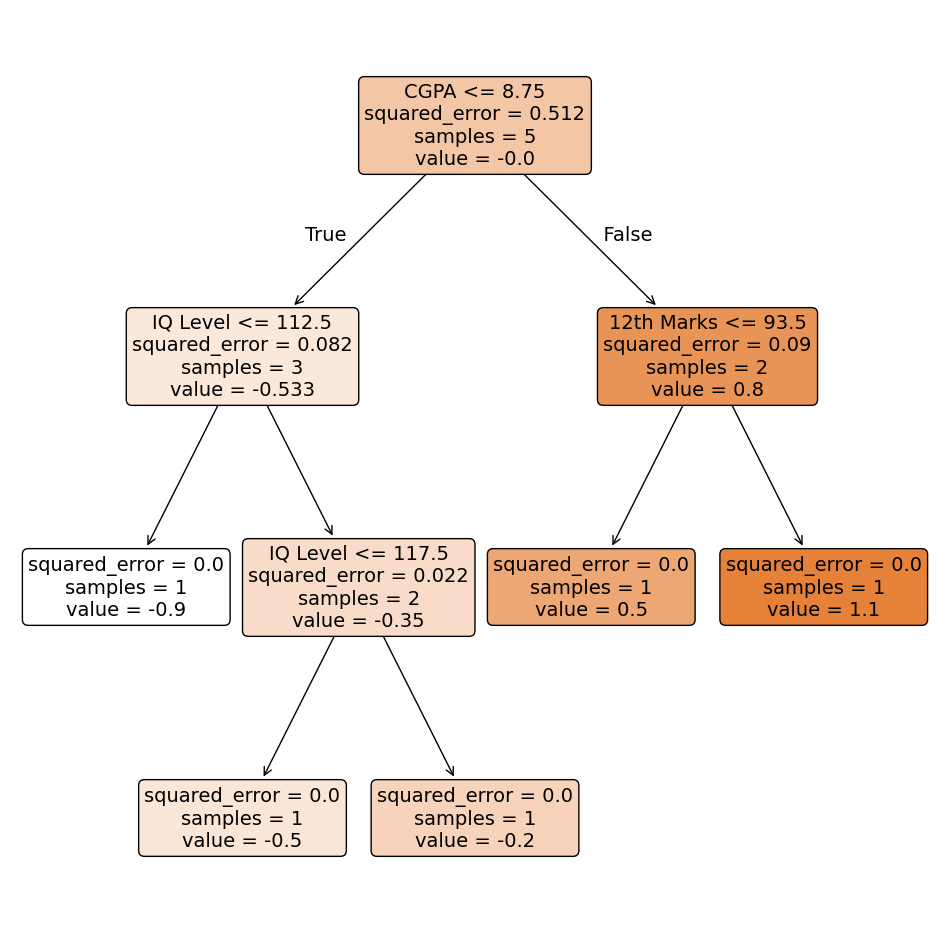

In [ ]:
tree1.fit(X.values,df['res1'].values)

from sklearn import tree

plt.figure(figsize=(12, 12))
tree.plot_tree(tree1, feature_names=X.columns, filled=True, rounded=True)
plt.show()

In [ ]:
df['pred2'] = 53500.0+0.3*tree1.predict(X)
df

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,CGPA,IQ Level,12th Marks,Salary,pred1,res1,pred2
0,8.5,120,85,7.5,7.7,-0.2,53499.94
1,9.0,130,92,8.2,7.7,0.5,53500.15
2,7.8,110,78,6.8,7.7,-0.9,53499.73
3,8.2,115,80,7.2,7.7,-0.5,53499.85
4,9.5,140,95,8.8,7.7,1.1,53500.33


In [ ]:
df['res2']= df['Salary']-df['pred2']
df

,CGPA,IQ Level,12th Marks,Salary,pred1,res1,pred2,res2
0,8.5,120,85,7.5,7.7,-0.2,53499.94,-53492.44
1,9.0,130,92,8.2,7.7,0.5,53500.15,-53491.95
2,7.8,110,78,6.8,7.7,-0.9,53499.73,-53492.93
3,8.2,115,80,7.2,7.7,-0.5,53499.85,-53492.65
4,9.5,140,95,8.8,7.7,1.1,53500.33,-53491.53


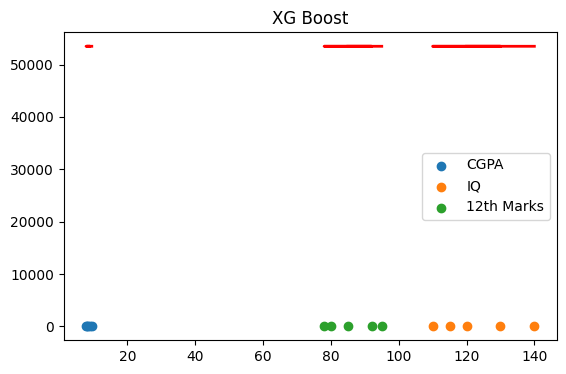

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X, df['pred2'], linewidth=2,color='red')
plt.scatter(df['CGPA'],df['Salary'],label="CGPA")
plt.scatter(df['IQ Level'],df['Salary'],label="IQ")
plt.scatter(df['12th Marks'],df['Salary'],label="12th Marks")
plt.title('XG Boost')
plt.legend()

plt.show()

In [ ]:
tree2= DecisionTreeRegressor(max_depth=5)
tree2.fit(X,df['res2'].values)

DecisionTreeRegressor(max_depth=5)

In [ ]:
df['pred3']= 53500.0+ sum(0.3 * reg.predict(X) for reg in [tree1,tree2])
df

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,CGPA,IQ Level,12th Marks,Salary,pred1,res1,pred2,res2,pred3
0,8.5,120,85,7.5,7.7,-0.2,53499.94,-53492.44,37452.208
1,9.0,130,92,8.2,7.7,0.5,53500.15,-53491.95,37452.565
2,7.8,110,78,6.8,7.7,-0.9,53499.73,-53492.93,37451.851
3,8.2,115,80,7.2,7.7,-0.5,53499.85,-53492.65,37452.055
4,9.5,140,95,8.8,7.7,1.1,53500.33,-53491.53,37452.871


In [ ]:
df['res3'] = df['Salary']- df['pred3']
df

,CGPA,IQ Level,12th Marks,Salary,pred1,res1,pred2,res2,pred3,res3
0,8.5,120,85,7.5,7.7,-0.2,53499.94,-53492.44,37452.208,-37444.708
1,9.0,130,92,8.2,7.7,0.5,53500.15,-53491.95,37452.565,-37444.365
2,7.8,110,78,6.8,7.7,-0.9,53499.73,-53492.93,37451.851,-37445.051
3,8.2,115,80,7.2,7.7,-0.5,53499.85,-53492.65,37452.055,-37444.855
4,9.5,140,95,8.8,7.7,1.1,53500.33,-53491.53,37452.871,-37444.071


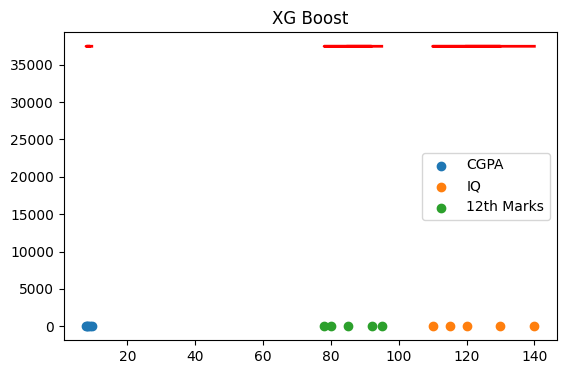

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X, df['pred3'], linewidth=2,color='red')
plt.scatter(df['CGPA'],df['Salary'],label="CGPA")
plt.scatter(df['IQ Level'],df['Salary'],label="IQ")
plt.scatter(df['12th Marks'],df['Salary'],label="12th Marks")
plt.title('XG Boost')
plt.legend()

plt.show()

In [ ]:
tree3= DecisionTreeRegressor(max_depth=5)
tree3.fit(X,df['res3'].values)

DecisionTreeRegressor(max_depth=5)

In [ ]:
df['pred 4']= 53500.0+ sum(0.3 * reg.predict(X) for reg in [tree1,tree2,tree3])
df

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,CGPA,IQ Level,12th Marks,Salary,pred1,res1,pred2,res2,pred3,res3,pred 4
0,8.5,120,85,7.5,7.7,-0.2,53499.94,-53492.44,37452.208,-37444.708,26218.7956
1,9.0,130,92,8.2,7.7,0.5,53500.15,-53491.95,37452.565,-37444.365,26219.2555
2,7.8,110,78,6.8,7.7,-0.9,53499.73,-53492.93,37451.851,-37445.051,26218.3357
3,8.2,115,80,7.2,7.7,-0.5,53499.85,-53492.65,37452.055,-37444.855,26218.5985
4,9.5,140,95,8.8,7.7,1.1,53500.33,-53491.53,37452.871,-37444.071,26219.6497


In [ ]:
df['res4'] = df['Salary']- df['pred 4']
df

,CGPA,IQ Level,12th Marks,Salary,pred1,res1,pred2,res2,pred3,res3,pred 4,res4
0,8.5,120,85,7.5,7.7,-0.2,53499.94,-53492.44,37452.208,-37444.708,26218.7956,-26211.2956
1,9.0,130,92,8.2,7.7,0.5,53500.15,-53491.95,37452.565,-37444.365,26219.2555,-26211.0555
2,7.8,110,78,6.8,7.7,-0.9,53499.73,-53492.93,37451.851,-37445.051,26218.3357,-26211.5357
3,8.2,115,80,7.2,7.7,-0.5,53499.85,-53492.65,37452.055,-37444.855,26218.5985,-26211.3985
4,9.5,140,95,8.8,7.7,1.1,53500.33,-53491.53,37452.871,-37444.071,26219.6497,-26210.8497


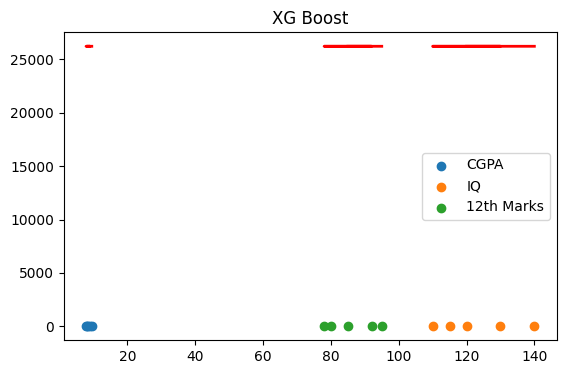

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X, df['pred 4'], linewidth=2,color='red')
plt.scatter(df['CGPA'],df['Salary'],label="CGPA")
plt.scatter(df['IQ Level'],df['Salary'],label="IQ")
plt.scatter(df['12th Marks'],df['Salary'],label="12th Marks")
plt.title('XG Boost')
plt.legend()

plt.show()

In [ ]:
tree4= DecisionTreeRegressor(max_depth=5)
tree4.fit(X,df['res4'].values)

DecisionTreeRegressor(max_depth=5)

In [ ]:
df['pred5']= 53500.0+ sum(0.3 * reg.predict(X) for reg in [tree1,tree2,tree3,tree4])
df

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,CGPA,IQ Level,12th Marks,Salary,pred1,res1,pred2,res2,pred3,res3,pred 4,res4,pred5
0,8.5,120,85,7.5,7.7,-0.2,53499.94,-53492.44,37452.208,-37444.708,26218.7956,-26211.2956,18355.40692
1,9.0,130,92,8.2,7.7,0.5,53500.15,-53491.95,37452.565,-37444.365,26219.2555,-26211.0555,18355.93885
2,7.8,110,78,6.8,7.7,-0.9,53499.73,-53492.93,37451.851,-37445.051,26218.3357,-26211.5357,18354.87499
3,8.2,115,80,7.2,7.7,-0.5,53499.85,-53492.65,37452.055,-37444.855,26218.5985,-26211.3985,18355.17895
4,9.5,140,95,8.8,7.7,1.1,53500.33,-53491.53,37452.871,-37444.071,26219.6497,-26210.8497,18356.39479


In [ ]:
df['res5'] = df['Salary']- df['pred5']
df

,CGPA,IQ Level,12th Marks,Salary,pred1,res1,pred2,res2,pred3,res3,pred 4,res4,pred5,res5
0,8.5,120,85,7.5,7.7,-0.2,53499.94,-53492.44,37452.208,-37444.708,26218.7956,-26211.2956,18355.40692,-18347.90692
1,9.0,130,92,8.2,7.7,0.5,53500.15,-53491.95,37452.565,-37444.365,26219.2555,-26211.0555,18355.93885,-18347.73885
2,7.8,110,78,6.8,7.7,-0.9,53499.73,-53492.93,37451.851,-37445.051,26218.3357,-26211.5357,18354.87499,-18348.07499
3,8.2,115,80,7.2,7.7,-0.5,53499.85,-53492.65,37452.055,-37444.855,26218.5985,-26211.3985,18355.17895,-18347.97895
4,9.5,140,95,8.8,7.7,1.1,53500.33,-53491.53,37452.871,-37444.071,26219.6497,-26210.8497,18356.39479,-18347.59479


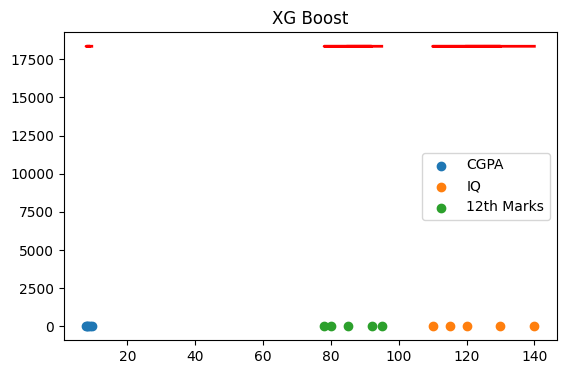

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X, df['pred5'], linewidth=2,color='red')
plt.scatter(df['CGPA'],df['Salary'],label="CGPA")
plt.scatter(df['IQ Level'],df['Salary'],label="IQ")
plt.scatter(df['12th Marks'],df['Salary'],label="12th Marks")
plt.title('XG Boost')
plt.legend()

plt.show()